# 第 12 章 · GAN 代码实验

[章节网页](../ch12.html)

## 运行内容

- 训练 sklearn 判别器
- 移动生成分布
- 绘制判别器评分

## 0. 环境与数据

In [1]:
# 导入实验库，并设置图表中文显示。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import display
from scipy.optimize import dual_annealing
from scipy.signal import correlate2d
from sklearn.datasets import load_digits
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# GAN 玩具过程：判别器由 sklearn MLPClassifier 训练，生成分布逐步靠近真实分布。
rng = np.random.default_rng(5)
fake_mean = -1.4
gan_rows = []

for step in range(1, 9):
    real = rng.normal(1.2, 0.35, size=120)
    fake = rng.normal(fake_mean, 0.45, size=120)
    X_disc = np.concatenate([real, fake]).reshape(-1, 1)
    y_disc = np.array([1] * len(real) + [0] * len(fake))
    disc = MLPClassifier(hidden_layer_sizes=(6,), max_iter=400, random_state=step)
    disc.fit(X_disc, y_disc)
    fake_score = disc.predict_proba(fake.reshape(-1, 1))[:, 1].mean()
    real_score = disc.predict_proba(real.reshape(-1, 1))[:, 1].mean()
    fake_mean += 0.28 * (real.mean() - fake.mean())
    gan_rows.append({
        "轮次": step,
        "生成均值": round(fake.mean(), 3),
        "D(real)": round(float(real_score), 3),
        "D(fake)": round(float(fake_score), 3),
    })

gan_trace = pd.DataFrame(gan_rows)
display(gan_trace)

,轮次,生成均值,D(real),D(fake)
0,1,-1.357,0.894,0.017
1,2,-0.637,0.838,0.133
2,3,-0.170,0.754,0.402
3,4,0.167,0.775,0.298
4,5,0.524,0.564,0.380
5,6,0.715,0.617,0.471
6,7,0.838,0.568,0.454
7,8,0.901,0.576,0.467


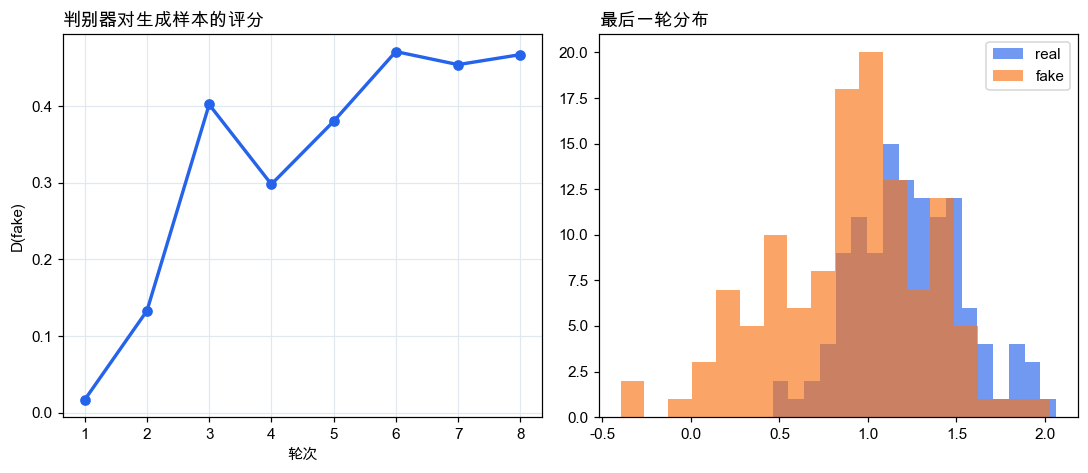

In [3]:
# 绘制 D(fake) 变化和最终一维分布。
fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.4))
axes[0].plot(gan_trace["轮次"], gan_trace["D(fake)"], marker="o", linewidth=2.2, color="#2563eb")
axes[0].set_title("判别器对生成样本的评分", loc="left", fontweight="bold")
axes[0].set_xlabel("轮次")
axes[0].set_ylabel("D(fake)")
axes[0].grid(True, color="#e2e8f0", linewidth=0.8)

axes[1].hist(real, bins=18, alpha=0.65, label="real", color="#2563eb")
axes[1].hist(fake, bins=18, alpha=0.65, label="fake", color="#f97316")
axes[1].set_title("最后一轮分布", loc="left", fontweight="bold")
axes[1].legend()
plt.tight_layout()
plt.show()